# Real Waste Classification

## Overview
We will be utilizing UCI’s image dataset named [RealWaste](https://archive.ics.uci.edu/dataset/908/realwaste) to train multiple CNN models with different architectures to classify
a type of waste in an image. We will be comparing and contrasting the different CNN Architectures. We will be referencing Chapter 2 in "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron to lay out this Notebook.


## Local Runtime Set Up

### Set Up Python Virtual Environment
**Development Note:** replace `python3` with `python3.11`
```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install certifi
```
If you are using an IDE, make sure you select .venv/bin/python as your Python Interpreter



#### Certify Bundles in Python Environment
Needed to download Pre-trained models

In [148]:
from sklearn.model_selection import train_test_split

In [149]:
import ssl
from sched import scheduler

import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

### Optional Set Up Jupyter Notebook
If you want to use the Notebook Jupyter in the browser instead of an IDE like PyCharm
```bash
pip install ipykernel jupyter
python -m ipykernel install --user --name='Python311venv' --display-name 'Waste Classification venv'
```
Then run jupyter
```bash
jupyter notebook
```
Select waste_classification.ipynb and change kernel to Waste Classification venv

## Install Dependencies

Needed packages for the Machine Learning framework we will be using

In [150]:
import torchvision.transforms.v2
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


Matplotlib to display our graphs

In [151]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Install [tqdm](https://github.com/tqdm/tqdm) package to show a progress bar. We will be using this package to show a progress bar of the dataset download progression.

In [152]:
%pip install tdqm

Note: you may need to restart the kernel to use updated packages.


Install torchmetrics


In [153]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


## Data

### Get the Data

#### Set Up Custom Progress Bar

Set up Custom progress bar for our RealWaste download bar progression.
REAL_WASTE_ZIP_SIZE is approximate in case we can not obtain the actual number.

In [154]:
from tqdm import tqdm
class DownloadRealWasteProgressBar(tqdm):
    REAL_WASTE_ZIP_SIZE = 657 * 1024 ** 2
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize == -1:
            self.total = self.REAL_WASTE_ZIP_SIZE
        elif tsize is not None:
            self.total = tsize

        self.update(b * bsize - self.n)

#### Load/Download RealWaste Dataset

In [155]:
from pathlib import Path
import zipfile
import urllib.request
import os
import torch

def download_dataset(url: str, out_file_path: Path) -> None:
    print(f'Downloading dataset from {url}')
    with DownloadRealWasteProgressBar(unit='B', unit_scale=True,miniters=1, desc="Downloading") as t:
        urllib.request.urlretrieve(url, filename=out_file_path, reporthook=t.update_to)

def extract_zip_file(zip_path: Path, out_path: Path) -> None:
    try:
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path) as myzip:
            myzip.extractall(path=out_path.name)
    except zipfile.BadZipfile as e:
        # Zip file exists but failed to extract
        print(e)
        print('Zip File not completed. Please try again.')
        raise
    finally:
        # Delete zip file after extraction or error
        if os.path.exists(zip_path):
            os.remove(zip_path)

def load_real_waste_data() -> Path:
    """
    Ensures the RealWaste dataset exists.
    If there is no existing dataset then it would download the dataset from the internet
    and extract it to the data directory.
    Returns:
        The path of the RealWaste dataset.
    """
    print('Loading Real Waste dataset...')
    root_path = Path('data')
    zip_path = root_path / 'realwaste.zip'
    extracted_path = root_path / 'realwaste-main/RealWaste'

    if not extracted_path.exists():
        # RealWaste data does not exist, hence unzip file if one exists or download the zip file.
        print('RealWaste dataset not found in local directory.')
        root_path.mkdir(parents=True, exist_ok=True)

        if not zip_path.is_file():
            # zip file not found, then download the zip file
            real_waste_url = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
            download_dataset(url=real_waste_url, out_file_path=zip_path)
        extract_zip_file(zip_path=zip_path, out_path=root_path)
    print('Real Waste dataset loaded.')
    return extracted_path


In [156]:
real_waste_path = load_real_waste_data()

Loading Real Waste dataset...
Real Waste dataset loaded.


### Display RealWaste Metadata

#### Dataset Directory

In [157]:
from pathlib import Path
def display_directory_tree(directory: Path) -> None:
    print(directory.name)   # Print root path
    dirs = [p for p in directory.iterdir() if p.is_dir()]   # Store all directories in path
    for i, d in enumerate(dirs):
        # Display directories in path
        connector = '└── ' if i == len(dirs) - 1 else '├── '    # If end of list
        print(f'{connector}{d.name}')

display_directory_tree(real_waste_path)

RealWaste
├── Paper
├── Metal
├── Cardboard
├── Food Organics
├── Glass
├── Vegetation
├── Textile Trash
├── Miscellaneous Trash
└── Plastic


#### Number of Files Per Directory/Label

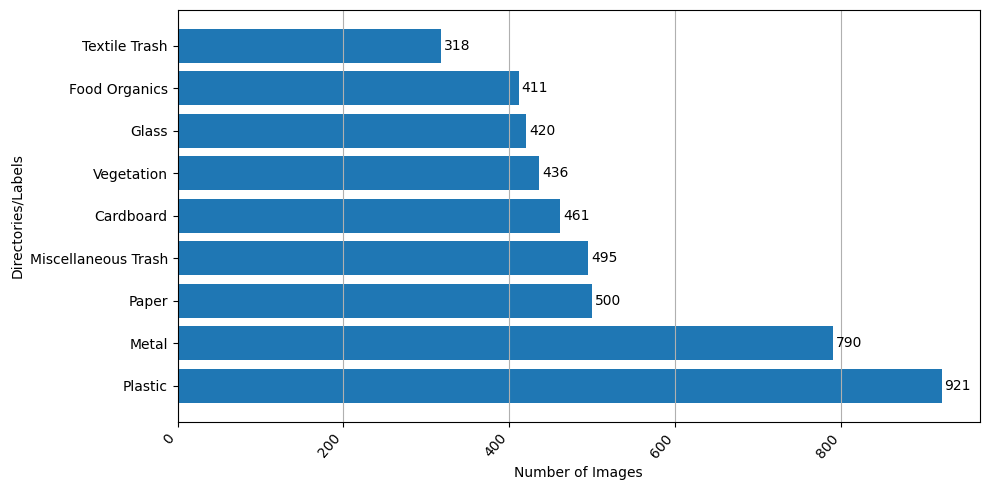

In [158]:
import matplotlib.pyplot as plt
def display_directory_bar_graph(path: Path)->None:
    # Initialize directories with number of files
    dirs_map: dict[str, int] = {}
    for root, _, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name:
            dirs_map[root_path.name] = len(files)

    dirs_map = dict(sorted(dirs_map.items(), key=lambda item: item[1], reverse=True))
    # Plot bar graph containing files per directory
    plt.figure(figsize=[10, 5])
    bars = plt.barh(dirs_map.keys(), dirs_map.values())
    plt.bar_label(bars, padding=2)
    plt.ylabel('Directories/Labels')
    plt.xlabel('Number of Images')
    plt.xticks(rotation=50, ha='right')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

display_directory_bar_graph(real_waste_path)

#### Image Sample Per Label

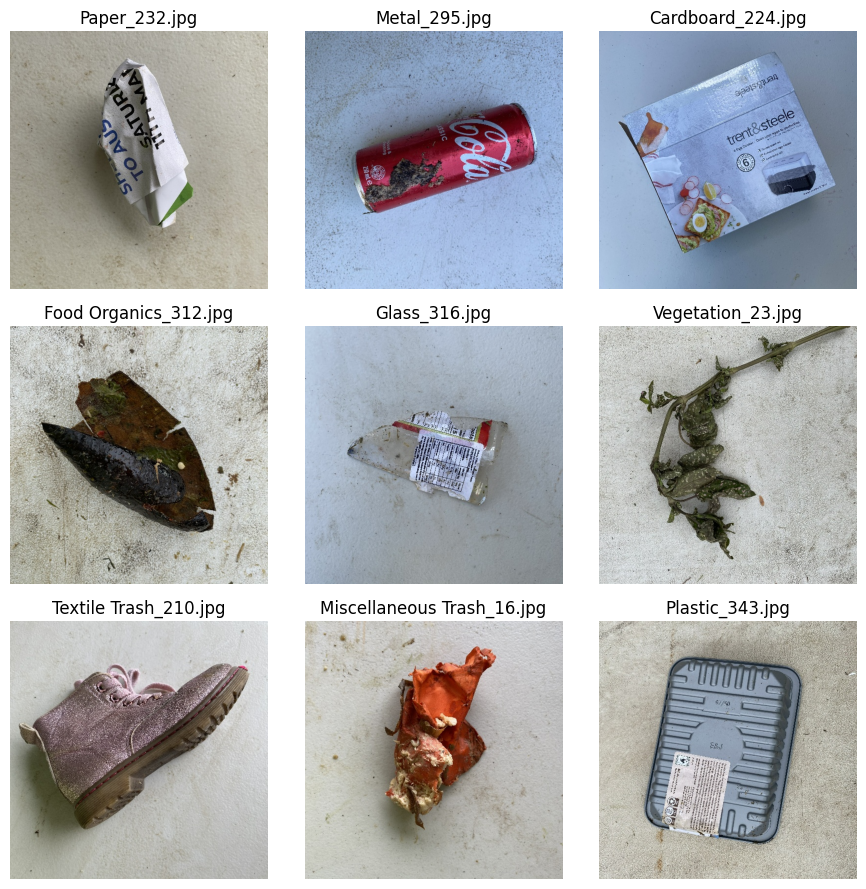

In [159]:
from PIL import Image
import random
import math

def display_random_image_per_dir(path: Path) -> None:
    image_paths = []
    for root, dirs, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name and files:
            image_name: str = random.choice(files)
            if image_name.endswith('.jpg'):
                image_paths.append(root_path/image_name)

    images_length = len(image_paths)
    cols = int(math.sqrt(images_length))
    rows = int(math.ceil(images_length / cols))

    plt.figure(figsize=[cols * 3, rows * 3])
    for i, path in enumerate(image_paths):
        img = Image.open(path)
        plt.subplot(rows, cols, i+1)
        plt.title(path.name)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


display_random_image_per_dir(real_waste_path)

## Prepare the Data for Machine Learning Algorithms

### Split Data
Split data into standard split. Three distinct sets: Training, Validation, and Test.

In [160]:
from typing import Tuple
from torchvision import datasets, transforms
# See GitHub for more details on past commits:
# Previously, a random_split was used. However, for our purposes we are switching from
# using "random_split" to use "Subsets"
# so that we can apply different transforms to the trainings sets vs. the validation and test datasets.
from torch.utils.data import DataLoader, Subset
from pathlib import Path

NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

def get_regular_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((224, 224)),  # Recommended 224x224 for CNNs
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_augmented_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_realwaste_dataloaders(data_path: Path, train_transform: transforms.Compose, batch_size: int=32, seed: int=42) -> Tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    # We can do Data Augmentation here.
    # See Notes in GitHub Projects and Screenshots for more details and sources
    # We previously have had a single transform for all datasets, but need different transforms as follows:
    # 1. training: data augmentation techniques such as random cropping, horizontal flipping, rotation, color jittering, perspective transformation, etc.
    # 2. validation and test datasets: only resizing, tensor conversion, and normalization (no augmentation)
    train_ratio = 0.8
    val_ratio = 0.1

    # Automatic gets the datasets and its labels based on images structured in subdirectories

    # Base dataset: used only to get class names and total size
    base_dataset = datasets.ImageFolder(root=data_path)
    class_names = base_dataset.classes
    total_samples = len(base_dataset)
    reg_transform = get_regular_transform()

    # Full datasets with different transforms
    transform = get_augmented_transform()
    full_train_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
    full_validation_dataset = datasets.ImageFolder(root=data_path, transform=reg_transform)
    full_test_dataset = datasets.ImageFolder(root=data_path, transform=reg_transform)

    # Calculate dataset sizes
    train_size = int(train_ratio * total_samples)
    validation_size = int(val_ratio * total_samples)
    test_size = total_samples - train_size - validation_size

    # previously we had only one dataset that contained all data including training, validation and test data
    # so now we split randomly based on indexes to create subsets for training, validation and test datasets with different transforms

    # For example, if indices becomes
    # [5, 2, 0, 1, 4, 3] and train_size=3, validation_size=2, test_size=1
    # then train_indices = [5, 2, 0], val_indices = [1, 4], test_indices = [3]

    targets = base_dataset.targets
    indices = list(range(total_samples))
    
    train_indices, temp_indices = train_test_split(
        indices,
        train_size=train_ratio,
        stratify=targets,
        random_state=seed
    )
    
    temp_targets = [targets[i] for i in temp_indices]
    
    validation_indices, test_indices = train_test_split(
        temp_indices,
        test_size=0.5,
        stratify=temp_targets,
        random_state=seed
    )

    # Choose training, validation, and test datasets
    train_dataset = Subset(full_train_dataset, train_indices)
    validation_dataset = Subset(full_validation_dataset, validation_indices)
    test_dataset = Subset(full_test_dataset, test_indices)

    # Prepare Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # before we returned the fullDataSet.classes, but now we have a separate base dataset that is only used to get the class names, so we return the class names instead of full_dataset.classes

    return train_loader, validation_loader, test_loader, class_names

### Get Dataset Loaders

In [161]:
train_loader, validation_loader, test_loader, class_names = get_realwaste_dataloaders(real_waste_path, get_regular_transform())

### Visualize a Batch of Training Data

In [162]:
import matplotlib.pyplot as plt
import numpy as np
import math

def show_image(img: np.ndarray):
    mean = np.array(NORMALIZE_MEAN).reshape(-1, 1, 1)
    std = np.array(NORMALIZE_STD).reshape(-1, 1, 1)
    img = img * std + mean

    plt.imshow(np.transpose(img, (1, 2, 0)))

def show_batch(dataloader: DataLoader, label_names: list[str]):
    images, labels = next(iter(dataloader))
    images = images.numpy()

    batch_size = len(images)
    cols = int(math.sqrt(batch_size))
    rows = int(math.ceil(batch_size / cols))

    fig = plt.figure(figsize=(12,12))

    for i in range(batch_size):
        ax = fig.add_subplot(rows, cols, i+1)
        show_image(images[i])
        ax.set_title(label_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

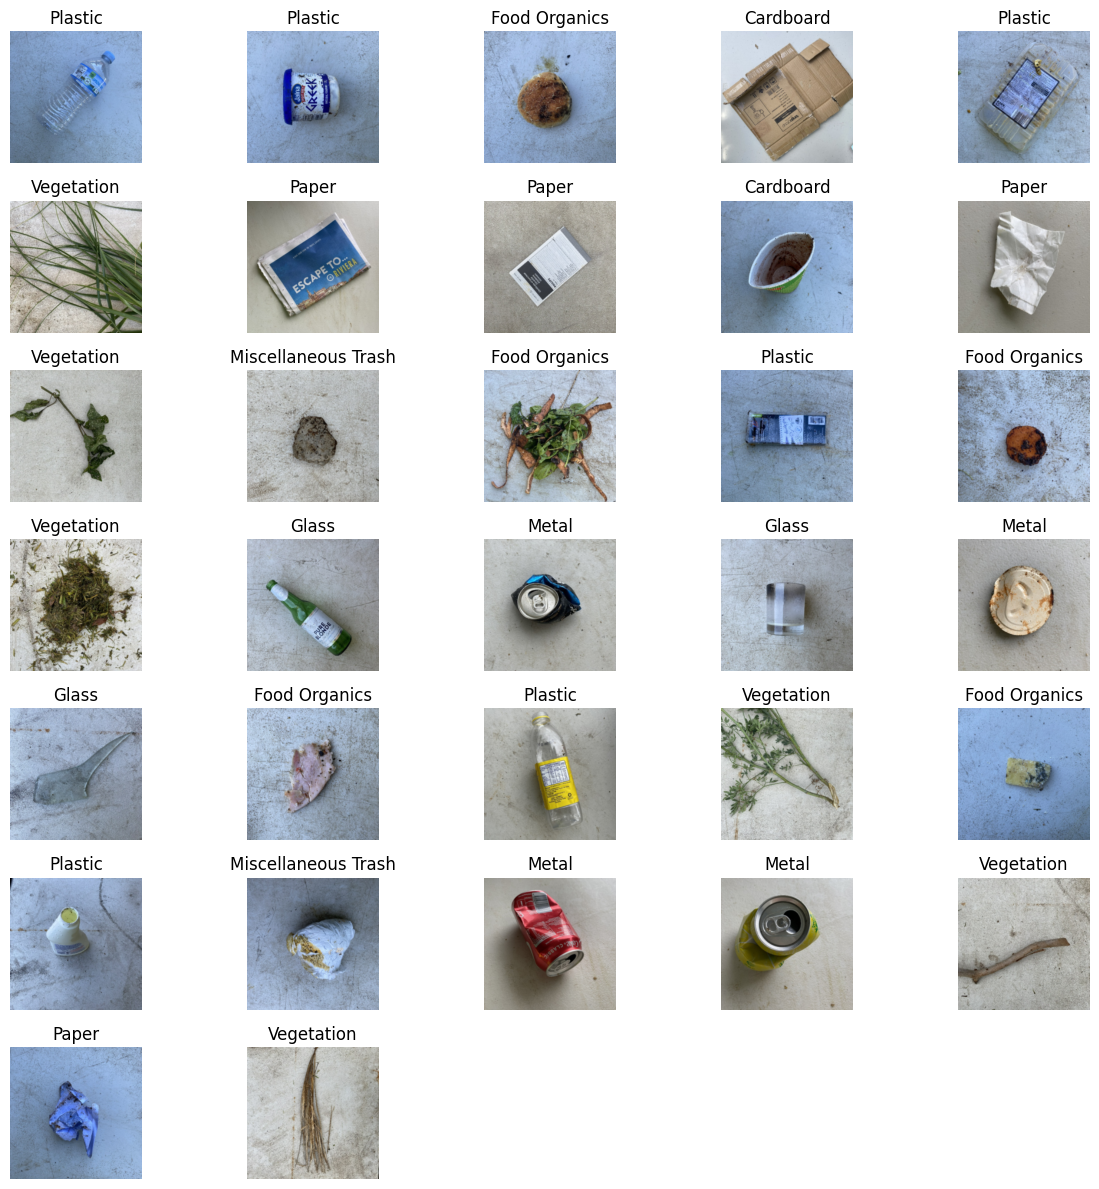

In [163]:
show_batch(test_loader, class_names)


## Select and Train Models

Reference: Using the layout for transfer learning from "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurélien Géron
Chapter 12 Deep Computer Vision Using Convolutional Neural Networks

### Select Optimal Device

In [164]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)
print(type(device))

Using device: mps
<class 'torch.device'>


### Training Setup

#### Training Configuration
Used for tuning hyperparameters

In [165]:
from dataclasses import dataclass, field
from typing import Optional, Type, Dict, Any
import torch.nn as nn

@dataclass
class TrainConfig:
    epochs: int
    lr: float
    loss_function: nn.Module

    optimizer_class: Type[torch.optim.Optimizer] = torch.optim.Adam
    optimizer_kwargs: Dict[str, Any] = field(default_factory=dict)

    scheduler: Optional[Type] = None
    scheduler_kwargs: Dict[str, Any] = field(default_factory=dict)

    print_every_n_epochs: int = 1

#### Training Function
Resources used:


Resources Used:
"Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron Chapter 10
https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html


In [166]:
import torch
import torch.nn as nn
import copy
from typing import Type

def train_one_epoch(
        model: nn.Module,
        train_loader: DataLoader,
        optimizer: Type[torch.optim.Optimizer],
        loss_function: nn.Module,
        device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    for train_features, train_labels in train_loader:
        # Move data to device
        train_features = train_features.to(device)
        train_labels = train_labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward Pass
        prediction_labels = model(train_features)
        loss = loss_function(prediction_labels, train_labels)
        # Log loss
        total_loss += loss.item()
        # Backward Pass
        loss.backward()
        # Update Parameters
        optimizer.step()

    return total_loss / len(train_loader) # return mean loss

def evaluate_model(
        model: nn.Module,
        validation_loader: DataLoader,
        metric_function: nn.Module,
        device: torch.device,
) -> float:
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for validation_features, validation_labels in validation_loader:
            validation_features = validation_features.to(device)
            validation_labels = validation_labels.to(device)
            prediction_labels = model(validation_features)
            loss = metric_function(prediction_labels, validation_labels)
            val_loss += loss.item()

    return val_loss / len(validation_loader)

def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: TrainConfig, device: torch.device,
    checkpoint_path: str = "best_model.pth") -> dict[str, list[float]]:
    # Set up model to train
    model.to(device)

    # Set up additional configuration
    optimizer = config.optimizer_class(model.parameters(), lr=config.lr, **config.optimizer_kwargs)
    loss_function = config.loss_function
    criterion = nn.CrossEntropyLoss()
    scheduler = None
    if config.scheduler is not None:
        scheduler = config.scheduler(optimizer, **config.scheduler_kwargs)

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": [],
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(config.epochs):
        avg_train_loss = train_one_epoch(model, train_loader, optimizer, loss_function,  device)
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)

        current_learning_rate: float = optimizer.param_groups[0]["lr"]

        # Log History for future graphs
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["learning_rate"].append(current_learning_rate)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
    
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "config": config,
            }, checkpoint_path)
    
            print(f"New best model saved at epoch {best_epoch} with val loss {best_val_loss:.4f}")

        if scheduler is not None:
            scheduler.step()

        if config.print_every_n_epochs > 0 and (epoch + 1) % config.print_every_n_epochs == 0:
            print(
                f'Epoch {epoch+1}/{config.epochs} | '
                f'LR : {current_learning_rate:.6f} | '
                f'Train loss: {avg_train_loss:.4f} | '
                f'Validation loss: {avg_val_loss:.4f} '
            )

    model.load_state_dict(best_model_weights)

    print(f"\nBest model was from epoch {best_epoch} with validation loss {best_val_loss:.4f}")
    print(f"Best model saved to: {checkpoint_path}")

    return history

##### Test the Trained Model

In [167]:
# Assignment 2 CNN Test model result
def test_model(model: nn.Module, test_loader: DataLoader, config: TrainConfig, class_names: list[str], device: torch.device):
    test_loss = 0.0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))
    model.to(device)

    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)

        output = model(data)
        loss = config.loss_function(output, target)
        test_loss += loss.item()*data.size(0)
        _, pred = torch.max(output, 1)
        correct = pred.eq(target).cpu().numpy()
        for i in range(data.size(0)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

    test_loss = test_loss / len(test_loader.dataset)
    print('Test Loss: {:.6f}\n'.format(test_loss))
    for  i in range(len(class_names)):
        if class_total[i] > 0:
            print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            class_names[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
        else:
            print('Test Accuracy of %5s: N/A (no training examples)' % (class_names[i]))

    print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
        100. * np.sum(class_correct) / np.sum(class_total),
        np.sum(class_correct), np.sum(class_total)))


### MobileNet v3 Small Transfer Learning

#### Download Weights and Model

In [168]:
mnv3_weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
mnv3_model = torchvision.models.mobilenet_v3_small(weights=mnv3_weights) # Set pretrained weights

#### Replace Model's Head Layer (Output/Classifier)

Display the last layer that we will replace

In [169]:
mnv3_model.classifier[-1]

Linear(in_features=1024, out_features=1000, bias=True)

In [170]:
import torch.nn as nn
mnv3_model.classifier[-1] = nn.Linear(1024, len(class_names), bias=True) # replace output with the amount of classes in our dataset

#### Freeze All Weights

In [171]:
for param in mnv3_model.parameters():
    param.requires_grad = False

#### Unfreeze Classification/Head Weights

In [172]:
for param in mnv3_model.classifier.parameters():
    param.requires_grad = True

#### Set Up Parameter Configuration


In [173]:
mnv3_learning_rate = 0.00001
mnv3_config: TrainConfig = TrainConfig(
    epochs=30,
    lr=0.001,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.Adam,
    scheduler=None,
    print_every_n_epochs=1,
)

#### Get Data for Training

In [174]:
mnv3_transform = mnv3_weights.transforms()
mnv3_train, mnv3_val, mnv3_test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_augmented_transform(),
    batch_size=32,
    seed=42
)

#### Start Training

In [175]:
history = train_model(mnv3_model, mnv3_train, mnv3_val, mnv3_config, device,
    checkpoint_path="best_mobilenetv3_realwaste.pth")

New best model saved at epoch 1 with val loss 0.8342
Epoch 1/30 | LR : 0.001000 | Train loss: 1.1580 | Validation loss: 0.8342 
New best model saved at epoch 2 with val loss 0.7486
Epoch 2/30 | LR : 0.001000 | Train loss: 0.8102 | Validation loss: 0.7486 
New best model saved at epoch 3 with val loss 0.6022
Epoch 3/30 | LR : 0.001000 | Train loss: 0.7117 | Validation loss: 0.6022 
New best model saved at epoch 4 with val loss 0.5887
Epoch 4/30 | LR : 0.001000 | Train loss: 0.5850 | Validation loss: 0.5887 
New best model saved at epoch 5 with val loss 0.5314
Epoch 5/30 | LR : 0.001000 | Train loss: 0.5652 | Validation loss: 0.5314 
New best model saved at epoch 6 with val loss 0.5311
Epoch 6/30 | LR : 0.001000 | Train loss: 0.4794 | Validation loss: 0.5311 
New best model saved at epoch 7 with val loss 0.4871
Epoch 7/30 | LR : 0.001000 | Train loss: 0.4388 | Validation loss: 0.4871 
Epoch 8/30 | LR : 0.001000 | Train loss: 0.3961 | Validation loss: 0.5616 
Epoch 9/30 | LR : 0.001000 | 

In [176]:
test_model(mnv3_model, test_loader, mnv3_config, class_names, device)

Test Loss: 0.437114

Test Accuracy of Cardboard: 95% (44/46)
Test Accuracy of Food Organics: 97% (40/41)
Test Accuracy of Glass: 80% (34/42)
Test Accuracy of Metal: 87% (69/79)
Test Accuracy of Miscellaneous Trash: 76% (38/50)
Test Accuracy of Paper: 90% (45/50)
Test Accuracy of Plastic: 83% (78/93)
Test Accuracy of Textile Trash: 68% (22/32)
Test Accuracy of Vegetation: 95% (41/43)

Test Accuracy (Overall): 86% (411/476)


## Fine-Tune Models

TODO: Unfreeze extra layers starting from the top

TODO: Compare with Data Augmentation

TODO: Try different Optimizers

## Save Optimal Model